# 05 — Classical Baselines (Subsampled)
**Project:** Quantum Machine Learning for Physiological Stress Classification  
**Author:** Kenza Qribis

---

## Purpose
Establish classical ML benchmark performance under LOSO cross-validation on WESAD and
DREAMER using a **stratified subsample of 150 windows per class per fold**.

## Why Subsampled?
Quantum models (notebooks 07–08) are computationally constrained to small datasets
on classical hardware simulators. To ensure a **fair, apples-to-apples comparison**,
all classical and quantum models are evaluated on identical data conditions.
This is standard practice in QML benchmarking literature (Havlicek et al., 2019).

Documented in methodology as:
> *All models were evaluated on a stratified subsample of 150 windows per class per
> LOSO fold. This constraint was imposed by the computational cost of quantum kernel
> estimation under NISQ-era simulation.*

## Models
- Logistic Regression, SVM (RBF kernel), Random Forest

## Datasets & Tasks
| Dataset  | Task           | Labels                               |
|----------|----------------|--------------------------------------|
| WESAD    | Binary         | baseline(0) vs stress(1)             |
| WESAD    | 3-class        | baseline(0), stress(1), amusement(2) |
| DREAMER  | Binary (EEG)   | low arousal(0) vs high arousal(1)    |

## Key Design Decisions
- StandardScaler fitted on train fold only
- Median imputation fitted on train fold only
- class_weight='balanced' on all models
- Subsampling: stratified, random_state fixed for reproducibility
- Same subsample size used in QSVM and VQC notebooks

---


## 0. Configuration

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

warnings.filterwarnings('ignore')

RESULTS_ROOT    = os.path.join('..', 'results')
PLOTS_DIR       = os.path.join(RESULTS_ROOT, 'plots', '05_classical_baselines')
LOGS_DIR        = os.path.join(RESULTS_ROOT, 'logs')
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, 'output_data')
for d in [PLOTS_DIR, LOGS_DIR, OUTPUT_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

ECG_FEATURE_PREFIXES = ['ecg_']
RANDOM_STATE = 42

# ── Subsampling config ────────────────────────────────────────────────────────
N_SAMPLES_PER_CLASS = 150   # same value used in QSVM and VQC notebooks

# ── Nested CV for hyperparameter search (inner loop, inside each LOSO fold) ───
INNER_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('Configuration ready.')
print(f'  Samples per class per fold : {N_SAMPLES_PER_CLASS}')
print(f'  Random state               : {RANDOM_STATE}')
print(f'  Inner CV (tuning)          : StratifiedKFold(5)')
print(f'  Plots dir                  : {os.path.abspath(PLOTS_DIR)}')

Configuration ready.
  Samples per class per fold : 150
  Random state               : 42
  Inner CV (tuning)          : StratifiedKFold(5)
  Plots dir                  : c:\Users\ACER\Desktop\APPLIED RESEARCH\Applied-Research\results\plots\05_classical_baselines


## 1. Load Datasets

In [2]:
# WESAD
df_wesad_bin = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'wesad_features_binary.csv'))
df_wesad_3cl = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'wesad_features_3class.csv'))
wesad_feat_cols = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'feature_columns.json')))

# DREAMER — EEG features only
df_dreamer = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_binary.csv'))
dreamer_all_feats = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'dreamer_feature_columns.json')))
dreamer_eeg_feats = [c for c in dreamer_all_feats
                     if not any(c.startswith(p) for p in ECG_FEATURE_PREFIXES)]

print('=== Datasets Loaded ===')
print(f'WESAD binary  : {df_wesad_bin.shape}  features={len(wesad_feat_cols)}')
print(f'WESAD 3-class : {df_wesad_3cl.shape}')
print(f'DREAMER binary: {df_dreamer.shape}  EEG features={len(dreamer_eeg_feats)}')

wesad_subjects   = sorted(df_wesad_bin['subject_id'].unique())
dreamer_subjects = sorted(df_dreamer['subject_id'].unique())
print(f'\nWESAD subjects  : {wesad_subjects}')
print(f'DREAMER subjects: {dreamer_subjects}')


=== Datasets Loaded ===
WESAD binary  : (883, 30)  features=26
WESAD 3-class : (1049, 30)
DREAMER binary: (414, 146)  EEG features=134

WESAD subjects  : [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]
DREAMER subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


## 1b. Fix DREAMER Ratings (if needed)
Only run this cell if `df_dreamer` is empty or has all-NaN arousal_binary.
Skips automatically if DREAMER is already correct.

In [3]:
if len(df_dreamer) == 0 or df_dreamer['arousal_binary'].isna().all():
    print('DREAMER ratings broken — re-extracting with correct keys...')
    from scipy.io import loadmat

    DREAMER_PATH = r"C:/Users/ACER/Desktop/APPLIED RESEARCH/Applied-Research/data/DREAMER/DREAMER.mat"
    mat      = loadmat(DREAMER_PATH, simplify_cells=True)
    data_all = mat['DREAMER']['Data']

    rating_rows = []
    for sid in range(23):
        s   = data_all[sid]
        val = np.array(s['ScoreValence']).flatten()
        aro = np.array(s['ScoreArousal']).flatten()
        dom = np.array(s['ScoreDominance']).flatten()
        for vid in range(len(aro)):
            rating_rows.append({
                'subject_id'    : sid + 1,
                'video_id'      : vid + 1,
                'valence'       : float(val[vid]),
                'arousal'       : float(aro[vid]),
                'dominance'     : float(dom[vid]),
                'arousal_binary': int(aro[vid] > 3),
                'valence_binary': int(val[vid] > 3),
            })

    df_ratings_fixed = pd.DataFrame(rating_rows)
    df_dreamer_full  = pd.read_csv(
        os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_all.csv'))
    drop_cols = ['valence','arousal','dominance','arousal_binary','valence_binary']
    df_dreamer_full = df_dreamer_full.drop(
        columns=[c for c in drop_cols if c in df_dreamer_full.columns])
    df_dreamer = df_dreamer_full.merge(
        df_ratings_fixed, on=['subject_id','video_id'], how='left')
    df_dreamer = df_dreamer.dropna(subset=['arousal_binary']).copy()
    df_dreamer['arousal_binary'] = df_dreamer['arousal_binary'].astype(int)

    p = os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_binary.csv')
    df_dreamer.to_csv(p, index=False)
    print(f'Fixed and saved: {p}')
    print(f'arousal_binary counts:\n{df_dreamer["arousal_binary"].value_counts()}')
else:
    print('DREAMER ratings OK — no fix needed.')
    print(f'arousal_binary counts:\n{df_dreamer["arousal_binary"].value_counts()}')

dreamer_subjects = sorted(df_dreamer['subject_id'].unique())
print(f'\nDREAMER subjects: {len(dreamer_subjects)}')


DREAMER ratings OK — no fix needed.
arousal_binary counts:
arousal_binary
0    233
1    181
Name: count, dtype: int64

DREAMER subjects: 23


## 2. Subsampling & Model Utilities

In [4]:
def stratified_subsample(X, y, n_per_class, random_state=42):
    """
    Subsample n_per_class examples from each class.
    If a class has fewer than n_per_class samples, take all of them
    and log a warning.
    """
    X_parts, y_parts = [], []
    rng = np.random.RandomState(random_state)
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        chosen = idx if len(idx) <= n_per_class \
                 else rng.choice(idx, size=n_per_class, replace=False)
        X_parts.append(X[chosen])
        y_parts.append(y[chosen])
    X_out = np.vstack(X_parts)
    y_out = np.concatenate(y_parts)
    perm  = rng.permutation(len(y_out))
    return X_out[perm], y_out[perm]


def compute_metrics(y_true, y_pred, average='macro'):
    return {
        'accuracy' : float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, average=average, zero_division=0)),
        'recall'   : float(recall_score(y_true, y_pred, average=average, zero_division=0)),
        'f1'       : float(f1_score(y_true, y_pred, average=average, zero_division=0)),
    }


# ── Tuned pipelines + hyperparameter grids ─────────────────────────────────
# SVM (RBF) gets the widest grid: it is the classical KERNEL method and is
# the direct, fair comparison point for QSVM. It also gets the same scaler
# choice (StandardScaler vs RobustScaler) already found to matter for the
# quantum kernel in 07_qsvm_experiments.ipynb.
def get_tuned_pipelines():
    return {
        'Logistic Regression': (
            Pipeline([
                ('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                            random_state=RANDOM_STATE)),
            ]),
            {'clf__C': [0.01, 0.1, 1, 10, 100]}
        ),
        'SVM (RBF)': (
            Pipeline([
                ('scaler', StandardScaler()),
                ('clf', SVC(kernel='rbf', class_weight='balanced',
                            probability=True, random_state=RANDOM_STATE)),
            ]),
            {
                'scaler': [StandardScaler(), RobustScaler()],
                'clf__C': [0.1, 1, 10, 100],
                'clf__gamma': ['scale', 'auto', 0.01, 0.1, 1],
            }
        ),
        'Random Forest': (
            Pipeline([
                ('scaler', StandardScaler()),
                ('clf', RandomForestClassifier(class_weight='balanced',
                                                random_state=RANDOM_STATE, n_jobs=-1)),
            ]),
            {
                'clf__n_estimators': [100, 200, 300],
                'clf__max_depth': [None, 5, 10, 20],
            }
        ),
    }


def run_loso_tuned(df, feature_cols, label_col, subject_col,
                    task_name='task', average='macro',
                    n_per_class=N_SAMPLES_PER_CLASS):
    """
    LOSO cross-validation with per-fold stratified subsampling AND a nested
    GridSearchCV (inner 5-fold StratifiedKFold on the training subsample)
    for every model. The held-out test subject is never touched by the
    search, so there is no leakage. Winning hyperparameters are logged per
    fold for the reproducibility appendix.
    """
    subjects = sorted(df[subject_col].unique())
    classes  = sorted(df[label_col].unique())
    n_cls    = len(classes)

    fold_rows   = []
    model_names = list(get_tuned_pipelines().keys())
    cm_dict     = {name: np.zeros((n_cls, n_cls), dtype=int) for name in model_names}
    all_preds   = {name: {'y_true': [], 'y_pred': []} for name in model_names}

    print(f'\n=== {task_name} — LOSO tuned ({len(subjects)} folds) ===')
    print(f'    Train subsample : {n_per_class} per class')
    print(f'    Test            : all windows for held-out subject')
    print(f'    Inner CV        : StratifiedKFold(5) for hyperparameter search')

    for fold_i, test_sid in enumerate(subjects):
        train_mask = df[subject_col] != test_sid
        test_mask  = df[subject_col] == test_sid

        X_train = df.loc[train_mask, feature_cols].values.astype(float)
        y_train = df.loc[train_mask, label_col].values
        X_test  = df.loc[test_mask,  feature_cols].values.astype(float)
        y_test  = df.loc[test_mask,  label_col].values

        imputer = SimpleImputer(strategy='median')
        X_train = imputer.fit_transform(X_train)
        X_test  = imputer.transform(X_test)

        X_train_sub, y_train_sub = stratified_subsample(
            X_train, y_train, n_per_class=n_per_class,
            random_state=RANDOM_STATE + fold_i)

        # NOTE: no pre-scaling here — scaling lives INSIDE each pipeline so
        # GridSearchCV can also search over which scaler wins per fold.
        for model_name, (pipeline, param_grid) in get_tuned_pipelines().items():
            t0 = time.time()
            search = GridSearchCV(pipeline, param_grid, cv=INNER_CV,
                                   scoring='f1_macro', n_jobs=-1)
            search.fit(X_train_sub, y_train_sub)
            train_time = time.time() - t0

            t0 = time.time()
            y_pred = search.predict(X_test)
            test_time = time.time() - t0

            metrics = compute_metrics(y_test, y_pred, average=average)
            cm      = confusion_matrix(y_test, y_pred, labels=classes)
            cm_dict[model_name] += cm

            all_preds[model_name]['y_true'].extend(y_test.tolist())
            all_preds[model_name]['y_pred'].extend(y_pred.tolist())

            best_params = {k: (v.__class__.__name__ if hasattr(v, 'fit') else v)
                           for k, v in search.best_params_.items()}

            fold_rows.append({
                'task'         : task_name,
                'model'        : model_name,
                'fold'         : fold_i + 1,
                'test_subject' : int(test_sid),
                'train_size'   : len(y_train_sub),
                'test_size'    : len(y_test),
                'train_time'   : round(train_time, 4),
                'test_time'    : round(test_time, 4),
                'best_params'  : json.dumps(best_params),
                **metrics
            })

        if (fold_i + 1) % 5 == 0 or fold_i == 0:
            print(f'  Fold {fold_i+1:2d}/{len(subjects)} — '
                  f'test=S{test_sid}  train_sub={len(y_train_sub)}  test={len(y_test)}')

    return pd.DataFrame(fold_rows), cm_dict, all_preds


print('Tuned utilities defined.')

Tuned utilities defined.


## 3. WESAD — Binary Task (baseline vs stress)

In [5]:
results_wb, cm_wb, preds_wb = run_loso_tuned(
    df           = df_wesad_bin,
    feature_cols = wesad_feat_cols,
    label_col    = 'label_encoded',
    subject_col  = 'subject_id',
    task_name    = 'WESAD_binary',
    average      = 'macro'
)
print('\n=== WESAD Binary — Mean Metrics ===')
print(results_wb.groupby('model')[['accuracy','precision','recall','f1',
                                    'train_time','test_time']]
      .mean().round(4).to_string())


=== WESAD_binary — LOSO tuned (15 folds) ===
    Train subsample : 150 per class
    Test            : all windows for held-out subject
    Inner CV        : StratifiedKFold(5) for hyperparameter search
  Fold  1/15 — test=S2  train_sub=300  test=56
  Fold  5/15 — test=S6  train_sub=300  test=59
  Fold 10/15 — test=S11  train_sub=300  test=59
  Fold 15/15 — test=S17  train_sub=300  test=61

=== WESAD Binary — Mean Metrics ===
                     accuracy  precision  recall      f1  train_time  test_time
model                                                                          
Logistic Regression    0.8543     0.8496  0.8382  0.8210      0.5166     0.0003
Random Forest          0.9023     0.9030  0.8943  0.8858      2.3759     0.0226
SVM (RBF)              0.8220     0.8282  0.8110  0.7882      0.3850     0.0005


## 4. WESAD — 3-Class Task (baseline / stress / amusement)

In [6]:
results_w3, cm_w3, preds_w3 = run_loso_tuned(
    df           = df_wesad_3cl,
    feature_cols = wesad_feat_cols,
    label_col    = 'label_encoded',
    subject_col  = 'subject_id',
    task_name    = 'WESAD_3class',
    average      = 'macro'
)
print('\n=== WESAD 3-Class — Mean Metrics ===')
print(results_w3.groupby('model')[['accuracy','precision','recall','f1',
                                    'train_time','test_time']]
      .mean().round(4).to_string())


=== WESAD_3class — LOSO tuned (15 folds) ===
    Train subsample : 150 per class
    Test            : all windows for held-out subject
    Inner CV        : StratifiedKFold(5) for hyperparameter search
  Fold  1/15 — test=S2  train_sub=450  test=67
  Fold  5/15 — test=S6  train_sub=450  test=70
  Fold 10/15 — test=S11  train_sub=450  test=70
  Fold 15/15 — test=S17  train_sub=450  test=72

=== WESAD 3-Class — Mean Metrics ===
                     accuracy  precision  recall      f1  train_time  test_time
model                                                                          
Logistic Regression    0.6376     0.6271  0.6540  0.5724      0.0900     0.0006
Random Forest          0.7044     0.7006  0.6842  0.6451      2.7323     0.0318
SVM (RBF)              0.5983     0.6242  0.5938  0.5206      0.8535     0.0018


## 5. DREAMER — Binary Task (EEG features only)

In [7]:
results_db, cm_db, preds_db = run_loso_tuned(
    df           = df_dreamer,
    feature_cols = dreamer_eeg_feats,
    label_col    = 'arousal_binary',
    subject_col  = 'subject_id',
    task_name    = 'DREAMER_binary_EEG',
    average      = 'macro'
)
print('\n=== DREAMER Binary EEG — Mean Metrics ===')
print(results_db.groupby('model')[['accuracy','precision','recall','f1',
                                    'train_time','test_time']]
      .mean().round(4).to_string())


=== DREAMER_binary_EEG — LOSO tuned (23 folds) ===
    Train subsample : 150 per class
    Test            : all windows for held-out subject
    Inner CV        : StratifiedKFold(5) for hyperparameter search
  Fold  1/23 — test=S1  train_sub=300  test=18
  Fold  5/23 — test=S5  train_sub=300  test=18
  Fold 10/23 — test=S10  train_sub=300  test=18
  Fold 15/23 — test=S15  train_sub=300  test=18
  Fold 20/23 — test=S20  train_sub=300  test=18

=== DREAMER Binary EEG — Mean Metrics ===
                     accuracy  precision  recall      f1  train_time  test_time
model                                                                          
Logistic Regression    0.4686     0.4599  0.4653  0.4336      0.1084     0.0006
Random Forest          0.5097     0.5318  0.5163  0.4664      3.0992     0.0268
SVM (RBF)              0.5242     0.5497  0.5266  0.4859      0.8210     0.0007


## 5b. SVM (RBF) — PCA-matched run (fair comparison vs QSVM)
QSVM is restricted to PCA-reduced inputs (3-4 components for WESAD, 4-6 for DREAMER).
This section reruns the tuned SVM (RBF) kernel at the same PCA dimensionality, so
the classical-vs-quantum kernel comparison is not confounded by input dimensionality.


In [8]:
def run_loso_svm_pca_matched(df, feature_cols, label_col, subject_col,
                              pca_components, task_name, average='macro',
                              n_per_class=N_SAMPLES_PER_CLASS):
    """
    Same protocol as run_loso_tuned, but restricted to SVM (RBF) and run once
    per PCA dimensionality in pca_components — mirrors the exact PCA grid used
    for QSVM in 07_qsvm_experiments.ipynb.
    """
    subjects = sorted(df[subject_col].unique())
    fold_rows = []

    param_grid = {
        'scaler': [StandardScaler(), RobustScaler()],
        'clf__C': [0.1, 1, 10, 100],
        'clf__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    }

    for n_comp in pca_components:
        print(f'\n--- {task_name} | SVM (RBF), PCA n_components={n_comp} ---')
        for fold_i, test_sid in enumerate(subjects):
            train_mask = df[subject_col] != test_sid
            test_mask  = df[subject_col] == test_sid

            X_train = df.loc[train_mask, feature_cols].values.astype(float)
            y_train = df.loc[train_mask, label_col].values
            X_test  = df.loc[test_mask,  feature_cols].values.astype(float)
            y_test  = df.loc[test_mask,  label_col].values

            imputer = SimpleImputer(strategy='median')
            X_train = imputer.fit_transform(X_train)
            X_test  = imputer.transform(X_test)

            X_train_sub, y_train_sub = stratified_subsample(
                X_train, y_train, n_per_class=n_per_class,
                random_state=RANDOM_STATE + fold_i)

            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('pca', PCA(n_components=n_comp, random_state=RANDOM_STATE)),
                ('clf', SVC(kernel='rbf', class_weight='balanced',
                            probability=True, random_state=RANDOM_STATE)),
            ])

            t0 = time.time()
            search = GridSearchCV(pipeline, param_grid, cv=INNER_CV,
                                   scoring='f1_macro', n_jobs=-1)
            search.fit(X_train_sub, y_train_sub)
            train_time = time.time() - t0

            y_pred = search.predict(X_test)
            metrics = compute_metrics(y_test, y_pred, average=average)

            best_params = {k: (v.__class__.__name__ if hasattr(v, 'fit') else v)
                           for k, v in search.best_params_.items()}

            fold_rows.append({
                'task'             : task_name,
                'model'            : 'SVM (RBF) PCA-matched',
                'n_pca_components' : n_comp,
                'fold'             : fold_i + 1,
                'test_subject'     : int(test_sid),
                'train_time'       : round(train_time, 4),
                'best_params'      : json.dumps(best_params),
                **metrics
            })

    return pd.DataFrame(fold_rows)


results_svm_pca_wb = run_loso_svm_pca_matched(
    df=df_wesad_bin, feature_cols=wesad_feat_cols, label_col='label_encoded',
    subject_col='subject_id', pca_components=[3, 4], task_name='WESAD_binary')

results_svm_pca_w3 = run_loso_svm_pca_matched(
    df=df_wesad_3cl, feature_cols=wesad_feat_cols, label_col='label_encoded',
    subject_col='subject_id', pca_components=[3, 4], task_name='WESAD_3class')

results_svm_pca_db = run_loso_svm_pca_matched(
    df=df_dreamer, feature_cols=dreamer_eeg_feats, label_col='arousal_binary',
    subject_col='subject_id', pca_components=[4, 6], task_name='DREAMER_binary_EEG')

results_svm_pca_all = pd.concat(
    [results_svm_pca_wb, results_svm_pca_w3, results_svm_pca_db], ignore_index=True)

print('\n=== SVM (RBF) PCA-matched — Mean F1 by task/n_components ===')
print(results_svm_pca_all.groupby(['task', 'n_pca_components'])['f1']
      .agg(['mean', 'std']).round(4).to_string())

p = os.path.join(OUTPUT_DATA_DIR, 'svm_pca_matched_results.csv')
results_svm_pca_all.to_csv(p, index=False)
print(f'\nSaved: {p}')


--- WESAD_binary | SVM (RBF), PCA n_components=3 ---

--- WESAD_binary | SVM (RBF), PCA n_components=4 ---

--- WESAD_3class | SVM (RBF), PCA n_components=3 ---

--- WESAD_3class | SVM (RBF), PCA n_components=4 ---

--- DREAMER_binary_EEG | SVM (RBF), PCA n_components=4 ---

--- DREAMER_binary_EEG | SVM (RBF), PCA n_components=6 ---

=== SVM (RBF) PCA-matched — Mean F1 by task/n_components ===
                                       mean     std
task               n_pca_components                
DREAMER_binary_EEG 4                 0.4623  0.1398
                   6                 0.4934  0.1363
WESAD_3class       3                 0.4584  0.1890
                   4                 0.4274  0.1925
WESAD_binary       3                 0.6871  0.2606
                   4                 0.7013  0.2367

Saved: ..\results\output_data\svm_pca_matched_results.csv


## 6. Results Summary Table

In [9]:
all_results = pd.concat([results_wb, results_w3, results_db], ignore_index=True)

summary_all = (
    all_results
    .groupby(['task','model'])
    .agg(
        accuracy_mean  = ('accuracy',   'mean'),
        accuracy_std   = ('accuracy',   'std'),
        precision_mean = ('precision',  'mean'),
        recall_mean    = ('recall',     'mean'),
        f1_mean        = ('f1',         'mean'),
        f1_std         = ('f1',         'std'),
        train_time_mean= ('train_time', 'mean'),
        test_time_mean = ('test_time',  'mean'),
    )
    .round(4)
    .reset_index()
)

print('=== CLASSICAL BASELINES — FULL SUMMARY ===')
print(f'(Subsampled: {N_SAMPLES_PER_CLASS} per class per fold)')
print(summary_all.to_string(index=False))

p = os.path.join(OUTPUT_DATA_DIR, 'classical_baselines_summary.csv')
summary_all.to_csv(p, index=False)
print(f'\nSaved: {p}')

p2 = os.path.join(OUTPUT_DATA_DIR, 'classical_baselines_per_fold.csv')
all_results.to_csv(p2, index=False)
print(f'Saved: {p2}')


=== CLASSICAL BASELINES — FULL SUMMARY ===
(Subsampled: 150 per class per fold)
              task               model  accuracy_mean  accuracy_std  precision_mean  recall_mean  f1_mean  f1_std  train_time_mean  test_time_mean
DREAMER_binary_EEG Logistic Regression         0.4686        0.0930          0.4599       0.4653   0.4336  0.1138           0.1084          0.0006
DREAMER_binary_EEG       Random Forest         0.5097        0.1486          0.5318       0.5163   0.4664  0.1411           3.0992          0.0268
DREAMER_binary_EEG           SVM (RBF)         0.5242        0.1252          0.5497       0.5266   0.4859  0.1097           0.8210          0.0007
      WESAD_3class Logistic Regression         0.6376        0.1741          0.6271       0.6540   0.5724  0.1748           0.0900          0.0006
      WESAD_3class       Random Forest         0.7044        0.1486          0.7006       0.6842   0.6451  0.1353           2.7323          0.0318
      WESAD_3class           SVM (RBF)

## 7. Confusion Matrices

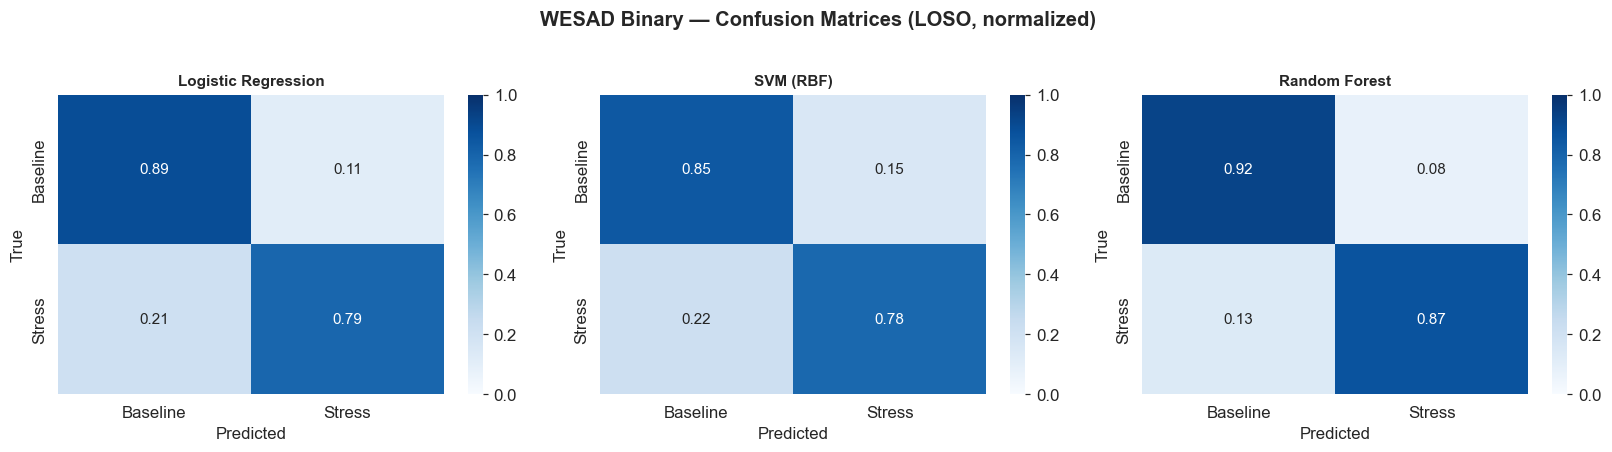

Saved: ..\results\plots\05_classical_baselines\cm_wesad_binary.png


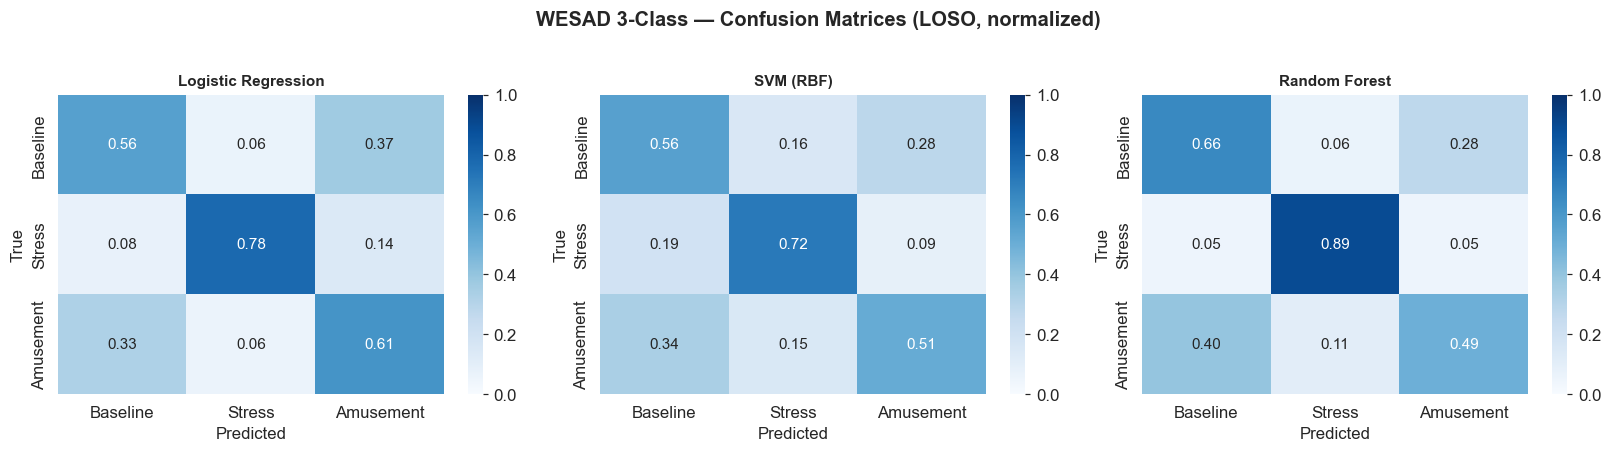

Saved: ..\results\plots\05_classical_baselines\cm_wesad_3class.png


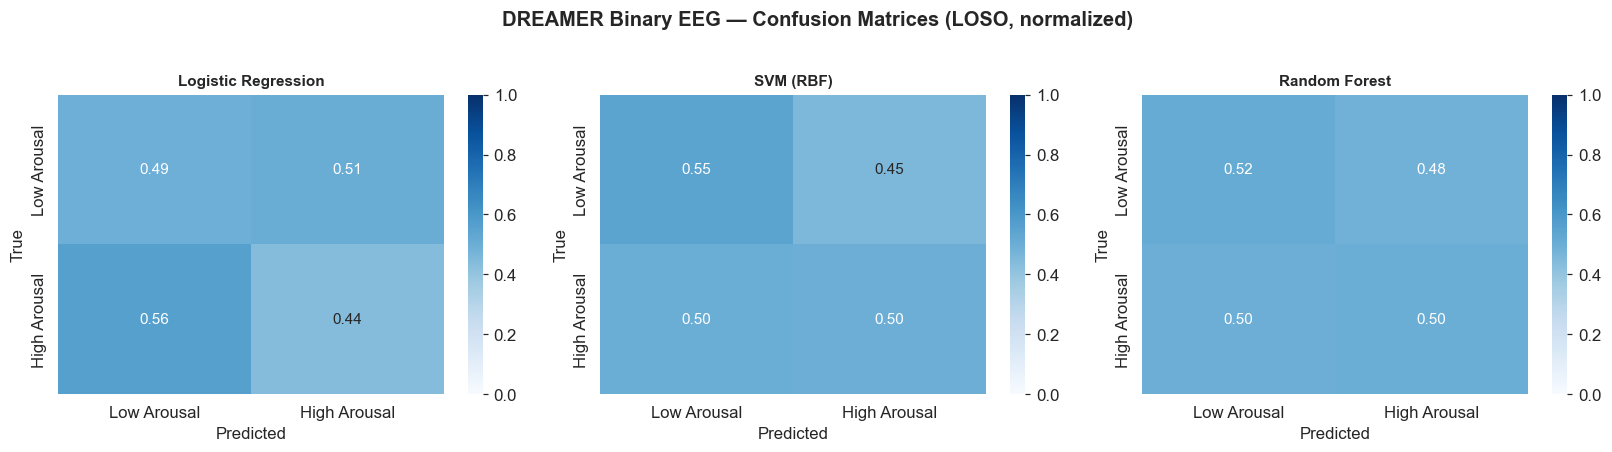

Saved: ..\results\plots\05_classical_baselines\cm_dreamer_binary.png


In [10]:
def plot_confusion_matrices(cm_dict, class_names, title, save_path):
    n = len(cm_dict)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]
    for ax, (model_name, cm) in zip(axes, cm_dict.items()):
        cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-10)
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, vmin=0, vmax=1, annot_kws={'size':10})
        ax.set_title(model_name, fontweight='bold', fontsize=10)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
    plt.suptitle(title, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

plot_confusion_matrices(
    cm_wb, ['Baseline','Stress'],
    'WESAD Binary — Confusion Matrices (LOSO, normalized)',
    os.path.join(PLOTS_DIR, 'cm_wesad_binary.png'))

plot_confusion_matrices(
    cm_w3, ['Baseline','Stress','Amusement'],
    'WESAD 3-Class — Confusion Matrices (LOSO, normalized)',
    os.path.join(PLOTS_DIR, 'cm_wesad_3class.png'))

plot_confusion_matrices(
    cm_db, ['Low Arousal','High Arousal'],
    'DREAMER Binary EEG — Confusion Matrices (LOSO, normalized)',
    os.path.join(PLOTS_DIR, 'cm_dreamer_binary.png'))


## 8. Performance Comparison Plots

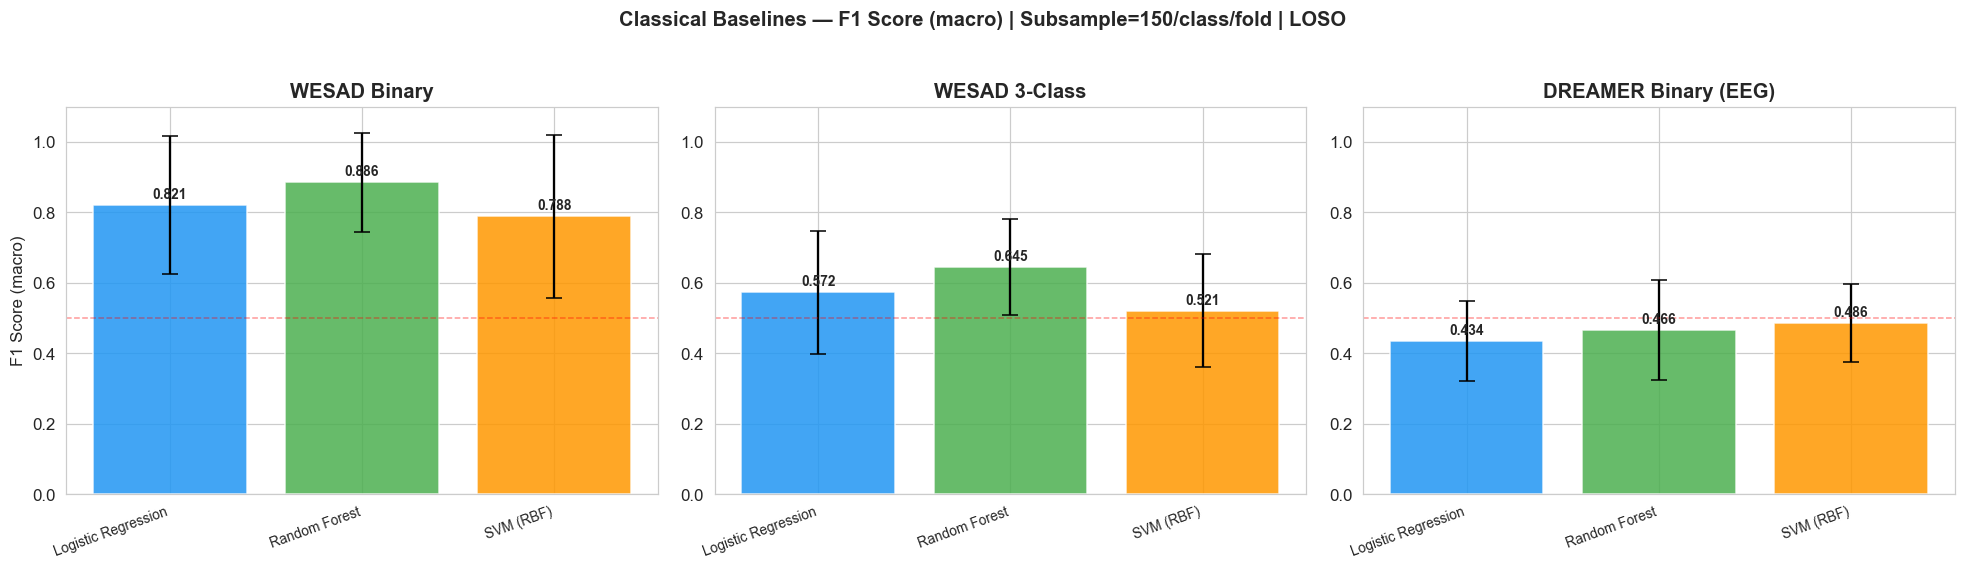

Saved: ..\results\plots\05_classical_baselines\classical_f1_comparison.png


In [11]:
tasks = [
    ('WESAD_binary',      'WESAD Binary'),
    ('WESAD_3class',      'WESAD 3-Class'),
    ('DREAMER_binary_EEG','DREAMER Binary (EEG)'),
]
model_colors = {
    'Logistic Regression': '#2196F3',
    'SVM (RBF)'          : '#FF9800',
    'Random Forest'      : '#4CAF50',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, (task_key, task_label) in zip(axes, tasks):
    td      = summary_all[summary_all['task'] == task_key]
    models  = td['model'].tolist()
    f1_m    = td['f1_mean'].tolist()
    f1_s    = td['f1_std'].tolist()
    colors  = [model_colors.get(m, 'gray') for m in models]
    bars    = ax.bar(models, f1_m, color=colors, alpha=0.85,
                     yerr=f1_s, capsize=5, edgecolor='white')
    for bar, val in zip(bars, f1_m):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    ax.set_title(task_label, fontweight='bold')
    ax.set_ylabel('F1 Score (macro)' if ax == axes[0] else '')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
    ax.axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.4, label='chance')

plt.suptitle(
    f'Classical Baselines — F1 Score (macro) | '
    f'Subsample={N_SAMPLES_PER_CLASS}/class/fold | LOSO',
    fontweight='bold', y=1.03)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'classical_f1_comparison.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


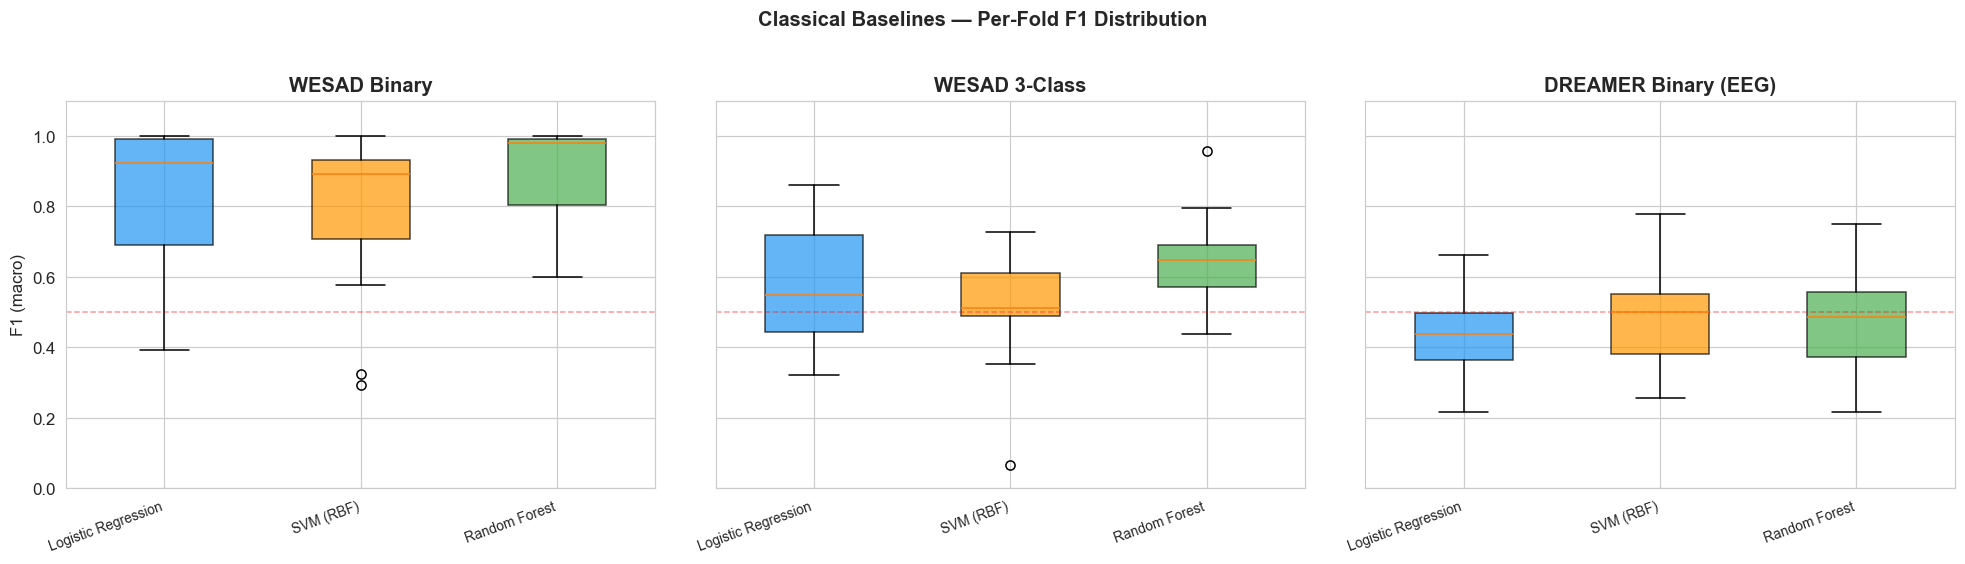

Saved: ..\results\plots\05_classical_baselines\classical_f1_per_fold_boxplot.png


In [12]:
# Per-fold F1 boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (task_key, task_label) in zip(axes, tasks):
    td          = all_results[all_results['task'] == task_key]
    model_names = list(td['model'].unique())
    data        = [td[td['model']==m]['f1'].values for m in model_names]
    bp = ax.boxplot(data, patch_artist=True,
                    labels=model_names, widths=0.5)
    for patch, m in zip(bp['boxes'], model_names):
        patch.set_facecolor(model_colors.get(m, 'gray'))
        patch.set_alpha(0.7)
    ax.set_title(task_label, fontweight='bold')
    ax.set_ylabel('F1 (macro)' if ax == axes[0] else '')
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.4)
plt.suptitle('Classical Baselines — Per-Fold F1 Distribution',
             fontweight='bold', y=1.02)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'classical_f1_per_fold_boxplot.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


## 9. WESAD 3-Class: Stress vs Amusement Overlap Analysis
Measures how often classical models confuse stress with amusement —
the baseline overlap rate that quantum models will be compared against.

In [13]:
print('=== Stress/Amusement Confusion (WESAD 3-class) ===')
print('Classes: 0=baseline  1=stress  2=amusement')
print()
overlap_rows = []
for model_name, cm in cm_w3.items():
    total_stress = cm[1, :].sum()
    total_amuse  = cm[2, :].sum()
    s_as_a = cm[1, 2]
    a_as_s = cm[2, 1]
    s_a_rate = s_as_a / total_stress if total_stress > 0 else 0
    a_s_rate = a_as_s / total_amuse  if total_amuse  > 0 else 0
    overlap_rows.append({
        'model'                  : model_name,
        'stress->amusement_rate' : round(s_a_rate, 4),
        'amusement->stress_rate' : round(a_s_rate, 4),
    })
    print(f'  {model_name}:')
    print(f'    Stress -> Amusement : {s_as_a}/{total_stress} ({s_a_rate*100:.1f}%)')
    print(f'    Amusement -> Stress : {a_as_s}/{total_amuse}  ({a_s_rate*100:.1f}%)')
    print()

df_overlap = pd.DataFrame(overlap_rows)
p = os.path.join(OUTPUT_DATA_DIR, 'classical_stress_amusement_overlap.csv')
df_overlap.to_csv(p, index=False)
print(f'Saved: {p}')
print('These rates are the classical baseline for the overlap problem.')
print('Quantum models will be compared against these in the results analysis.')


=== Stress/Amusement Confusion (WESAD 3-class) ===
Classes: 0=baseline  1=stress  2=amusement

  Logistic Regression:
    Stress -> Amusement : 45/313 (14.4%)
    Amusement -> Stress : 10/166  (6.0%)

  SVM (RBF):
    Stress -> Amusement : 27/313 (8.6%)
    Amusement -> Stress : 25/166  (15.1%)

  Random Forest:
    Stress -> Amusement : 16/313 (5.1%)
    Amusement -> Stress : 18/166  (10.8%)

Saved: ..\results\output_data\classical_stress_amusement_overlap.csv
These rates are the classical baseline for the overlap problem.
Quantum models will be compared against these in the results analysis.


## 10. Summary Log

In [14]:
summary_dict = {
    'notebook'          : '05_classical_baselines',
    'timestamp'         : datetime.now().isoformat(),
    'subsampling'       : {
        'n_per_class'   : N_SAMPLES_PER_CLASS,
        'applied_to'    : 'train fold only',
        'test_set'      : 'all windows for held-out subject (no subsampling)',
        'justification' : 'Matches quantum model evaluation conditions'
    },
    'models'            : ['Logistic Regression', 'SVM (RBF)', 'Random Forest'],
    'tasks'             : [
        'WESAD_binary', 'WESAD_3class', 'DREAMER_binary_EEG'],
    'evaluation'        : 'Leave-One-Subject-Out (LOSO)',
    'results'           : {}
}

for _, row in summary_all.iterrows():
    key = f"{row['task']}|{row['model']}"
    summary_dict['results'][key] = {
        'accuracy_mean': row['accuracy_mean'],
        'f1_mean'      : row['f1_mean'],
        'f1_std'       : row['f1_std'],
        'train_time_s' : row['train_time_mean'],
    }

summary_dict['next'] = '06_cnn_baseline.ipynb'

p = os.path.join(LOGS_DIR, '05_classical_baselines_summary.json')
with open(p,'w') as f: json.dump(summary_dict, f, indent=2)

print('=' * 60)
print('CLASSICAL BASELINES COMPLETE')
print('=' * 60)
print(json.dumps(summary_dict, indent=2))
print(f'\nLog saved: {p}')


CLASSICAL BASELINES COMPLETE
{
  "notebook": "05_classical_baselines",
  "timestamp": "2026-09-09T19:20:24.372393",
  "subsampling": {
    "n_per_class": 150,
    "applied_to": "train fold only",
    "test_set": "all windows for held-out subject (no subsampling)",
    "justification": "Matches quantum model evaluation conditions"
  },
  "models": [
    "Logistic Regression",
    "SVM (RBF)",
    "Random Forest"
  ],
  "tasks": [
    "WESAD_binary",
    "WESAD_3class",
    "DREAMER_binary_EEG"
  ],
  "evaluation": "Leave-One-Subject-Out (LOSO)",
  "results": {
    "DREAMER_binary_EEG|Logistic Regression": {
      "accuracy_mean": 0.4686,
      "f1_mean": 0.4336,
      "f1_std": 0.1138,
      "train_time_s": 0.1084
    },
    "DREAMER_binary_EEG|Random Forest": {
      "accuracy_mean": 0.5097,
      "f1_mean": 0.4664,
      "f1_std": 0.1411,
      "train_time_s": 3.0992
    },
    "DREAMER_binary_EEG|SVM (RBF)": {
      "accuracy_mean": 0.5242,
      "f1_mean": 0.4859,
      "f1_std": 0.